# Explore heuristic values for an empty maze

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Create the maze representation

Define an empty $10 \times 10$ maze and place the start and goal. The figures retain one-based coordinate labels, while the NumPy array uses zero-based indices.

In [ ]:
n = 10
start = np.array([1, 1])
goal = np.array([8, 8])

maze = np.full((n, n), " ", dtype=str)
maze[tuple(start)] = "S"
maze[tuple(goal)] = "G"
maze

array([[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', 'S', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'G', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']], dtype='<U1')

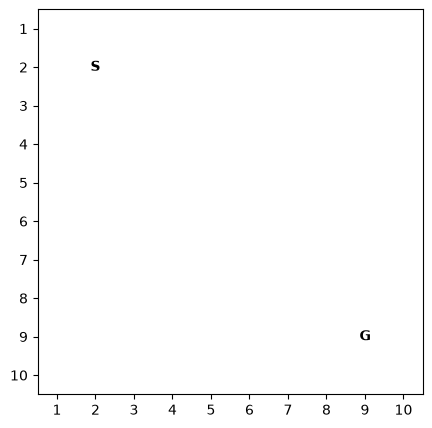

In [ ]:
def show_values(values, cmap="YlOrRd_r", colorbar=True):
    """Display values on the maze and mark the start and goal."""
    figure, axis = plt.subplots(figsize=(6, 5))
    image = axis.imshow(values, cmap=cmap, origin="upper")
    axis.set_xticks(range(n), labels=range(1, n + 1))
    axis.set_yticks(range(n), labels=range(1, n + 1))
    axis.text(goal[1], goal[0], "G", ha="center", va="center", fontweight="bold")
    axis.text(start[1], start[0], "S", ha="center", va="center", fontweight="bold")
    if colorbar:
        figure.colorbar(image, ax=axis, label="value")
    plt.show()


show_values(np.zeros((n, n)), cmap="Greys", colorbar=False)

## Greedy Best-First Search: Use Manhattan Distance for $h(n)$

Manhattan distance is also called the $L_1$ norm. It is the difference in x values plus the difference in y values: $L_1(a,b) = |a_x-b_x| + |a_y-b_y|$.

Manhattan distance is a perfect heuristic for the maze: $h(n) = h^*(n)$ and $f(n) = f^*(n)$ (the asterisk represents the optimal value). Calculate $h(n)$.

[[16 15 14 13 12 11 10  9  8  9]
 [15 14 13 12 11 10  9  8  7  8]
 [14 13 12 11 10  9  8  7  6  7]
 [13 12 11 10  9  8  7  6  5  6]
 [12 11 10  9  8  7  6  5  4  5]
 [11 10  9  8  7  6  5  4  3  4]
 [10  9  8  7  6  5  4  3  2  3]
 [ 9  8  7  6  5  4  3  2  1  2]
 [ 8  7  6  5  4  3  2  1  0  1]
 [ 9  8  7  6  5  4  3  2  1  2]]


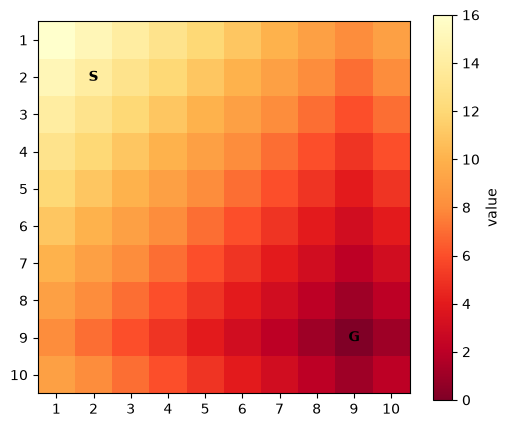

In [ ]:
rows, columns = np.indices((n, n))
h_manhattan = np.abs(rows - goal[0]) + np.abs(columns - goal[1])
print(h_manhattan)
show_values(h_manhattan)

The algorithm will follow the color gradient from light yellow to dark red.

## A* with Manhattan heuristic

Calculate $f(n) = g(n) + h(n)$.

[[18 16 16 16 16 16 16 16 16 18]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [18 16 16 16 16 16 16 16 16 18]]


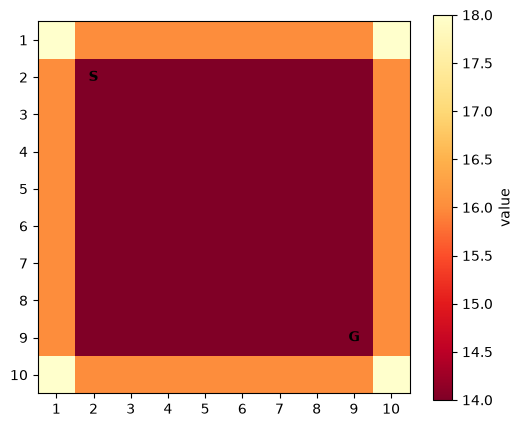

In [ ]:
g = np.abs(rows - start[0]) + np.abs(columns - start[1])
f = g + h_manhattan
print(f)
show_values(f)

**Note:** In Manhattan geometry, all paths that go directly from $S$ to $G$ are optimal and have the same distance. Even with a perfect heuristic, the agent faces a plateau of positions with exactly the same $f(n) = C^*$. All directions are tied, so the tie-breaking strategy is important. For A* search with a reached data structure, this means that all states in the red square will be explored leading to very inefficient search!

[Amit Patel's discussion of heuristics](http://theory.stanford.edu/~amitp/GameProgramming/Heuristics.html) describes this and other issues and suggests increasing the value of $h(n)$ by a small factor, leading to weighted A* search.

## Weighted A* Search

Use $f(n) = g(n) + W \times h(n)$, with $W > 0$. For $W>1$, this is not guaranteed to be optimal because the weighted heuristic may become inadmissible, but it can reduce search time and memory. First, inflate the heuristic by 10%.

[[19.6 17.5 17.4 17.3 17.2 17.1 17.  16.9 16.8 18.9]
 [17.5 15.4 15.3 15.2 15.1 15.  14.9 14.8 14.7 16.8]
 [17.4 15.3 15.2 15.1 15.  14.9 14.8 14.7 14.6 16.7]
 [17.3 15.2 15.1 15.  14.9 14.8 14.7 14.6 14.5 16.6]
 [17.2 15.1 15.  14.9 14.8 14.7 14.6 14.5 14.4 16.5]
 [17.1 15.  14.9 14.8 14.7 14.6 14.5 14.4 14.3 16.4]
 [17.  14.9 14.8 14.7 14.6 14.5 14.4 14.3 14.2 16.3]
 [16.9 14.8 14.7 14.6 14.5 14.4 14.3 14.2 14.1 16.2]
 [16.8 14.7 14.6 14.5 14.4 14.3 14.2 14.1 14.  16.1]
 [18.9 16.8 16.7 16.6 16.5 16.4 16.3 16.2 16.1 18.2]]


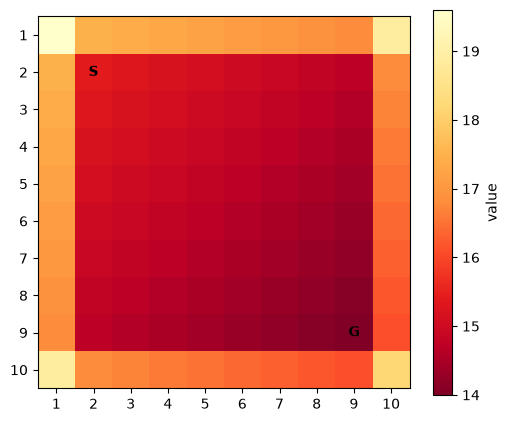

In [ ]:
f = g + 1.10 * h_manhattan
print(f)
show_values(f)

The weighting create a slight gradient that leads directly from $S$ to $G$. Now try $W=5$. As $W$ increases, weighted A* approaches greedy best-first search (GBFS), which completely ignores $g(n)$.

[[82 76 72 68 64 60 56 52 48 54]
 [76 70 66 62 58 54 50 46 42 48]
 [72 66 62 58 54 50 46 42 38 44]
 [68 62 58 54 50 46 42 38 34 40]
 [64 58 54 50 46 42 38 34 30 36]
 [60 54 50 46 42 38 34 30 26 32]
 [56 50 46 42 38 34 30 26 22 28]
 [52 46 42 38 34 30 26 22 18 24]
 [48 42 38 34 30 26 22 18 14 20]
 [54 48 44 40 36 32 28 24 20 26]]


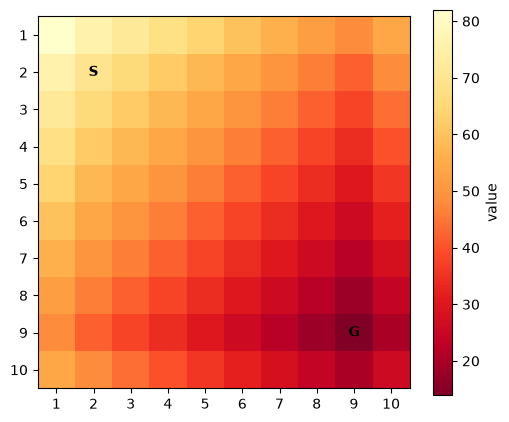

In [ ]:
f = g + 5 * h_manhattan
print(f)
show_values(f)

Using $W<1$ makes the search behave more like uniform-cost search (BFS when every step has the same cost). This leads to exploring the area around $S$ first and very inefficient search.

[[10.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  13.5]
 [ 8.5  7.   7.5  8.   8.5  9.   9.5 10.  10.5 12. ]
 [ 9.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  12.5]
 [ 9.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 13. ]
 [10.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  13.5]
 [10.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 14. ]
 [11.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  14.5]
 [11.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 15. ]
 [12.  10.5 11.  11.5 12.  12.5 13.  13.5 14.  15.5]
 [13.5 12.  12.5 13.  13.5 14.  14.5 15.  15.5 17. ]]


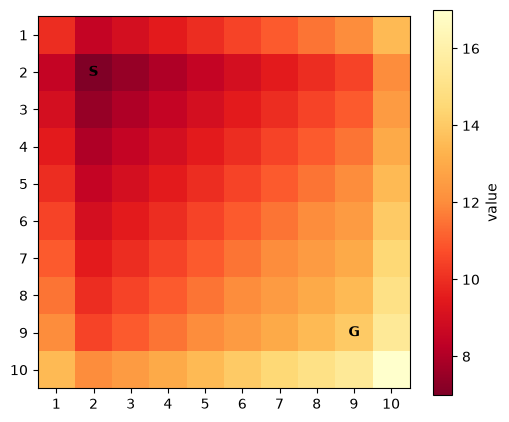

In [ ]:
f = g + 0.5 * h_manhattan
print(f)
show_values(f)

## Greedy Best-First Search with Euclidean Distance for $h(n)$

Euclidean distance is the $L_2$ norm: $L_2(a,b) = \sqrt{(a_x-b_x)^2 + (a_y-b_y)^2}$. It is not perfect when the true cost follows Manhattan distance, but it is admissible: $h(n) \leq h^*(n)$.

[[11.3137 10.6301 10.      9.434   8.9443  8.544   8.2462  8.0623  8.
   8.0623]
 [10.6301  9.8995  9.2195  8.6023  8.0623  7.6158  7.2801  7.0711  7.
   7.0711]
 [10.      9.2195  8.4853  7.8102  7.2111  6.7082  6.3246  6.0828  6.
   6.0828]
 [ 9.434   8.6023  7.8102  7.0711  6.4031  5.831   5.3852  5.099   5.
   5.099 ]
 [ 8.9443  8.0623  7.2111  6.4031  5.6569  5.      4.4721  4.1231  4.
   4.1231]
 [ 8.544   7.6158  6.7082  5.831   5.      4.2426  3.6056  3.1623  3.
   3.1623]
 [ 8.2462  7.2801  6.3246  5.3852  4.4721  3.6056  2.8284  2.2361  2.
   2.2361]
 [ 8.0623  7.0711  6.0828  5.099   4.1231  3.1623  2.2361  1.4142  1.
   1.4142]
 [ 8.      7.      6.      5.      4.      3.      2.      1.      0.
   1.    ]
 [ 8.0623  7.0711  6.0828  5.099   4.1231  3.1623  2.2361  1.4142  1.
   1.4142]]


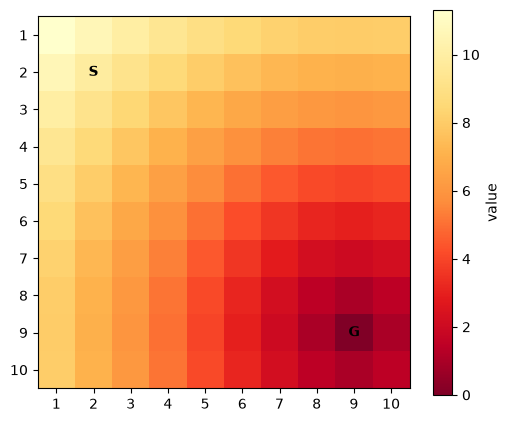

In [ ]:
h_euclidean = np.hypot(rows - goal[0], columns - goal[1])
print(h_euclidean)
show_values(h_euclidean)

## A* with Euclidean Distance for $h(n)$

[[13.3137 11.6301 12.     12.434  12.9443 13.544  14.2462 15.0623 16.
  17.0623]
 [11.6301  9.8995 10.2195 10.6023 11.0623 11.6158 12.2801 13.0711 14.
  15.0711]
 [12.     10.2195 10.4853 10.8102 11.2111 11.7082 12.3246 13.0828 14.
  15.0828]
 [12.434  10.6023 10.8102 11.0711 11.4031 11.831  12.3852 13.099  14.
  15.099 ]
 [12.9443 11.0623 11.2111 11.4031 11.6569 12.     12.4721 13.1231 14.
  15.1231]
 [13.544  11.6158 11.7082 11.831  12.     12.2426 12.6056 13.1623 14.
  15.1623]
 [14.2462 12.2801 12.3246 12.3852 12.4721 12.6056 12.8284 13.2361 14.
  15.2361]
 [15.0623 13.0711 13.0828 13.099  13.1231 13.1623 13.2361 13.4142 14.
  15.4142]
 [16.     14.     14.     14.     14.     14.     14.     14.     14.
  16.    ]
 [17.0623 15.0711 15.0828 15.099  15.1231 15.1623 15.2361 15.4142 16.
  17.4142]]


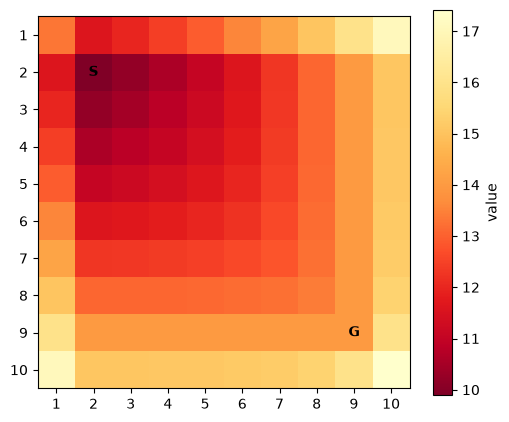

In [ ]:
f = g + h_euclidean
print(f)
show_values(f)

**Note:** Euclidean and Manhattan geometry do not mix well here; the gradient is actually from the goal toward the start.
          A* expands every node with $f(n)<C^*$ and some nodes with $f(n)=C^*$. These nodes are shown in black below.

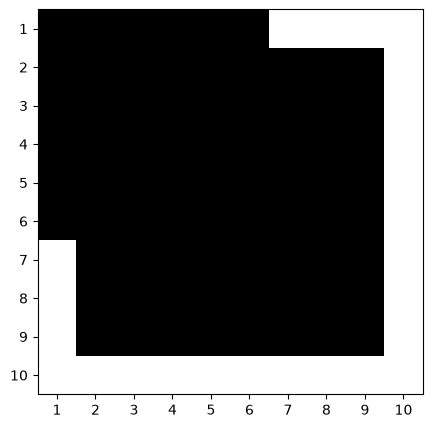

In [ ]:
optimal_cost = f[tuple(goal)]
show_values(f <= optimal_cost, cmap="Greys", colorbar=False)

# Conclusion

We need to be careful when choosing heuristics to make sure that we still create a clear gradient for A* to follow. Otherwise, we will end up with an algorithm that is as inefficient as BFS. 

# Bài 6 — Ảnh hưởng của heuristic

Phần bổ sung này giữ nguyên các thí nghiệm phía trên và tập trung trả lời bốn yêu cầu:

1. Quan sát đồng thời bản đồ $h(n)$ và $f(n)$ trong mê cung rỗng.
2. Chạy thực nghiệm Manhattan và Euclidean với cả GBFS và A*.
3. Giải thích vì sao Manhattan phù hợp hơn cho lưới chỉ đi bốn hướng.
4. Đề xuất heuristic khác và nêu điều kiện để A* vẫn tối ưu.

> Để so sánh công bằng, mọi thí nghiệm dùng cùng mê cung 10×10, cùng thứ tự sinh láng giềng `N, E, S, W`, graph search và FIFO khi các nút bằng điểm ưu tiên. Quy tắc phá hòa có thể làm thay đổi số nút mở rộng, nhưng không thay đổi các tính chất toán học của heuristic.

## 6.1. Quan sát trực quan $h(n)$ và $f(n)$

Với một trạng thái $n=(r,c)$ và đích $G=(r_G,c_G)$:

- Manhattan: $h_M(n)=|r-r_G|+|c-c_G|$.
- Euclidean: $h_E(n)=\sqrt{(r-r_G)^2+(c-c_G)^2}$.
- A* sử dụng $f(n)=g(n)+h(n)$; trong mê cung rỗng, $g(n)$ dưới đây là khoảng cách ngắn nhất từ `S` đến $n$.

Con số trong mỗi ô là giá trị heuristic/đánh giá tại trạng thái đó.

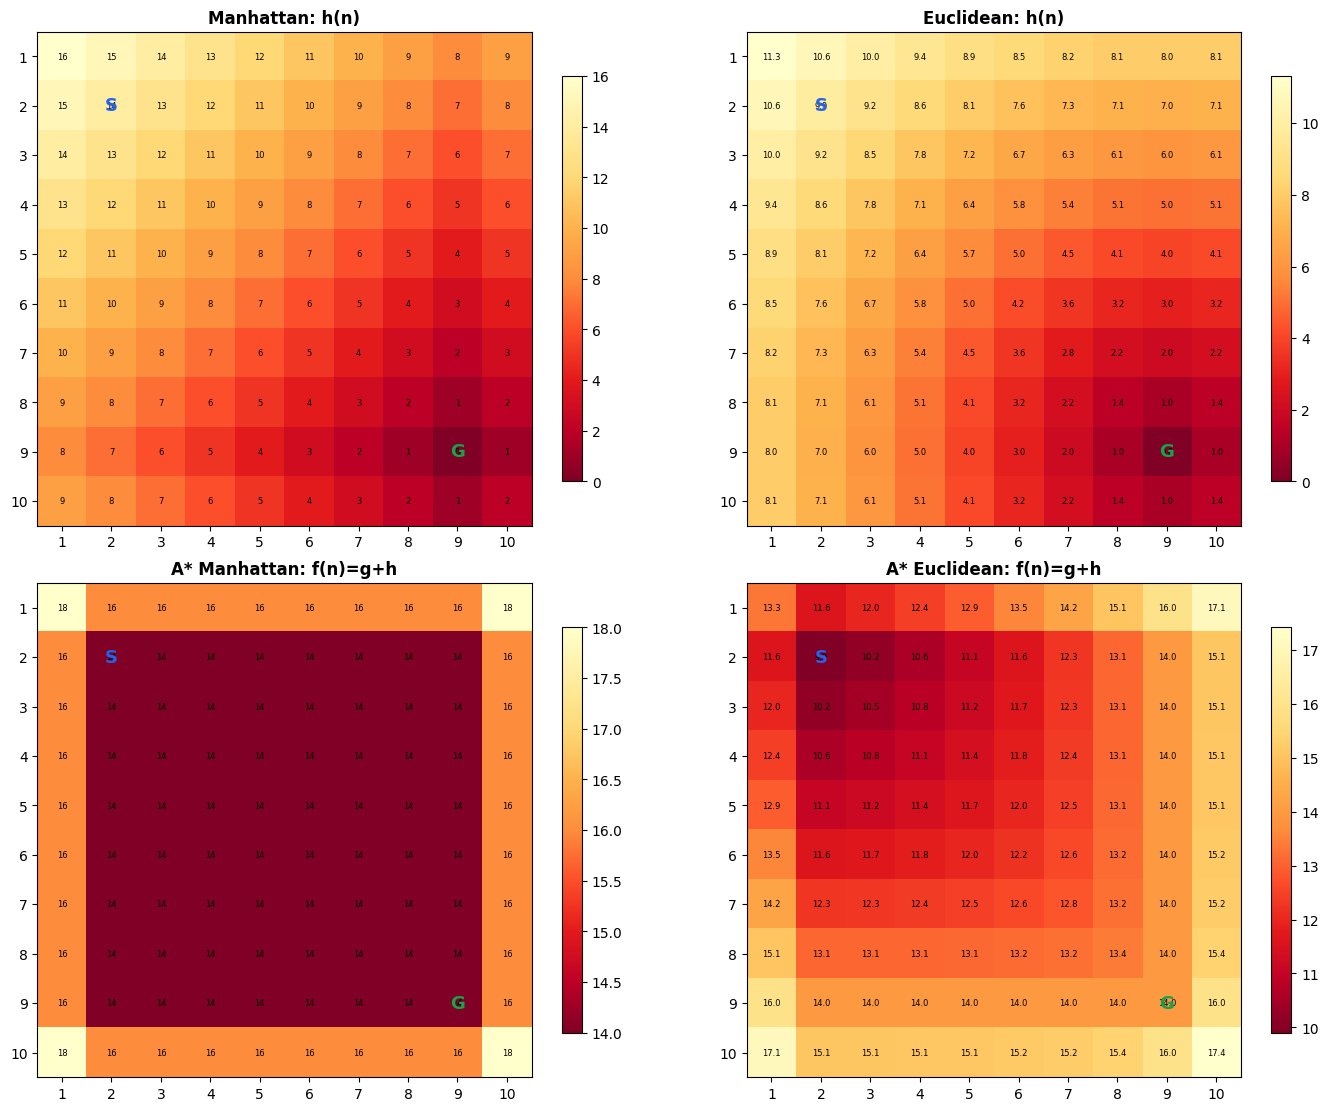

In [ ]:
# Tính lại với tên biến rõ nghĩa để không phụ thuộc giá trị f ở cell trước.
g_from_start = np.abs(rows - start[0]) + np.abs(columns - start[1])
f_manhattan = g_from_start + h_manhattan
f_euclidean = g_from_start + h_euclidean

value_maps = [
    ('Manhattan: h(n)', h_manhattan),
    ('Euclidean: h(n)', h_euclidean),
    ('A* Manhattan: f(n)=g+h', f_manhattan),
    ('A* Euclidean: f(n)=g+h', f_euclidean),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
for axis, (title, values) in zip(axes.flat, value_maps):
    image = axis.imshow(values, cmap='YlOrRd_r', origin='upper')
    axis.set_title(title, fontweight='bold')
    axis.set_xticks(range(n), labels=range(1, n + 1))
    axis.set_yticks(range(n), labels=range(1, n + 1))
    for row in range(n):
        for column in range(n):
            label = f'{values[row, column]:.1f}' if values.dtype.kind == 'f' else str(values[row, column])
            axis.text(column, row, label, ha='center', va='center', fontsize=6)
    axis.text(start[1], start[0], 'S', ha='center', va='center',
              color='#2563eb', fontsize=13, fontweight='bold')
    axis.text(goal[1], goal[0], 'G', ha='center', va='center',
              color='#16a34a', fontsize=13, fontweight='bold')
    fig.colorbar(image, ax=axis, shrink=0.82)
plt.show()

### Nhận xét từ bản đồ giá trị

- Tại `S`, chi phí thật trong mê cung rỗng là 14. Manhattan cho đúng 14, còn Euclidean chỉ cho $\sqrt{7^2+7^2}\approx9.90$. Manhattan vì vậy chứa nhiều thông tin hơn.
- Các đường đồng mức Manhattan có dạng hình thoi/các cạnh song song với lưới; Euclidean có dạng gần tròn như khoảng cách đường thẳng. Tác tử lại không được đi chéo, nên hình học Manhattan khớp với mô hình hành động hơn.
- Với Manhattan, mọi ô trong hình chữ nhật từ `S` đến `G` nằm trên một đường đi tối ưu nào đó và có $f=14$. Đây là một **plateau** lớn; thứ tự phá hòa quyết định A* gặp `G` sớm hay phải mở rộng nhiều ô cùng $f$.
- Với Euclidean, nhiều ô có $f<14$. A* bắt buộc mở rộng tất cả các nút có $f<C^*=14$ trước khi lấy đích ra khỏi frontier.

## 6.2. So sánh Manhattan và Euclidean cho GBFS và A*

GBFS ưu tiên $h(n)$ và bỏ qua chi phí đã đi $g(n)$. A* ưu tiên $f(n)=g(n)+h(n)$. Để bảng kết quả dễ kiểm tra, ta dùng một cài đặt graph search nhỏ, độc lập với module lời giải của giảng viên.

In [ ]:
import heapq
import itertools
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import display

MOVES = [('N', -1, 0), ('E', 0, 1), ('S', 1, 0), ('W', 0, -1)]
start_state, goal_state = tuple(start), tuple(goal)

def manhattan(state):
    return abs(state[0] - goal_state[0]) + abs(state[1] - goal_state[1])

def euclidean(state):
    return np.hypot(state[0] - goal_state[0], state[1] - goal_state[1])

def neighbors(state):
    for action, dr, dc in MOVES:
        child = (state[0] + dr, state[1] + dc)
        if 0 <= child[0] < n and 0 <= child[1] < n:
            yield action, child

def best_first_search(strategy, heuristic):
    counter = itertools.count()  # FIFO để phá hòa
    frontier = []
    best_g = {start_state: 0}
    parent = {start_state: None}
    parent_action = {}
    closed = set()
    expanded_order = []
    max_frontier = 0

    def push(state, path_cost):
        priority = heuristic(state) if strategy == 'GBFS' else path_cost + heuristic(state)
        heapq.heappush(frontier, (priority, next(counter), path_cost, state))

    push(start_state, 0)
    while frontier:
        priority, _, path_cost, state = heapq.heappop(frontier)
        if state in closed or path_cost != best_g[state]:
            continue
        if state == goal_state:
            break

        closed.add(state)
        expanded_order.append(state)
        for action, child in neighbors(state):
            new_g = path_cost + 1
            if child not in closed and new_g < best_g.get(child, np.inf):
                best_g[child] = new_g
                parent[child] = state
                parent_action[child] = action
                push(child, new_g)
        max_frontier = max(max_frontier, len(frontier))

    path, actions, current = [goal_state], [], goal_state
    while current != start_state:
        actions.append(parent_action[current])
        current = parent[current]
        path.append(current)
    path.reverse()
    actions.reverse()
    return {
        'strategy': strategy, 'path': path, 'actions': actions,
        'path_cost': len(actions), 'expanded': len(expanded_order),
        'expanded_order': expanded_order, 'generated': len(best_g),
        'max_frontier': max_frontier,
    }

In [ ]:
heuristics = {'Manhattan': manhattan, 'Euclidean': euclidean}
results = []
for strategy in ('GBFS', 'A*'):
    for heuristic_name, heuristic in heuristics.items():
        result = best_first_search(strategy, heuristic)
        result['heuristic'] = heuristic_name
        result['h_start'] = heuristic(start_state)
        results.append(result)

comparison = pd.DataFrame([
    {
        'thuật toán': result['strategy'],
        'heuristic': result['heuristic'],
        'h(S)': round(result['h_start'], 4),
        'chi phí đường đi': result['path_cost'],
        'nút mở rộng': result['expanded'],
        'trạng thái được sinh': result['generated'],
        'frontier lớn nhất': result['max_frontier'],
    }
    for result in results
])
display(comparison.style.hide(axis='index').set_caption('Manhattan và Euclidean trên cùng điều kiện tìm kiếm'))

# Trong mê cung rỗng này, cả bốn phép chạy đều tìm được đường dài 14.
assert all(result['path_cost'] == 14 for result in results)
a_star = {result['heuristic']: result for result in results if result['strategy'] == 'A*'}
assert a_star['Manhattan']['expanded'] <= a_star['Euclidean']['expanded']

thuật toán,heuristic,h(S),chi phí đường đi,nút mở rộng,trạng thái được sinh,frontier lớn nhất
GBFS,Manhattan,14.000000,14,14,43,29
GBFS,Euclidean,9.899500,14,14,32,18
A*,Manhattan,14.000000,14,63,94,31
A*,Euclidean,9.899500,14,74,95,21


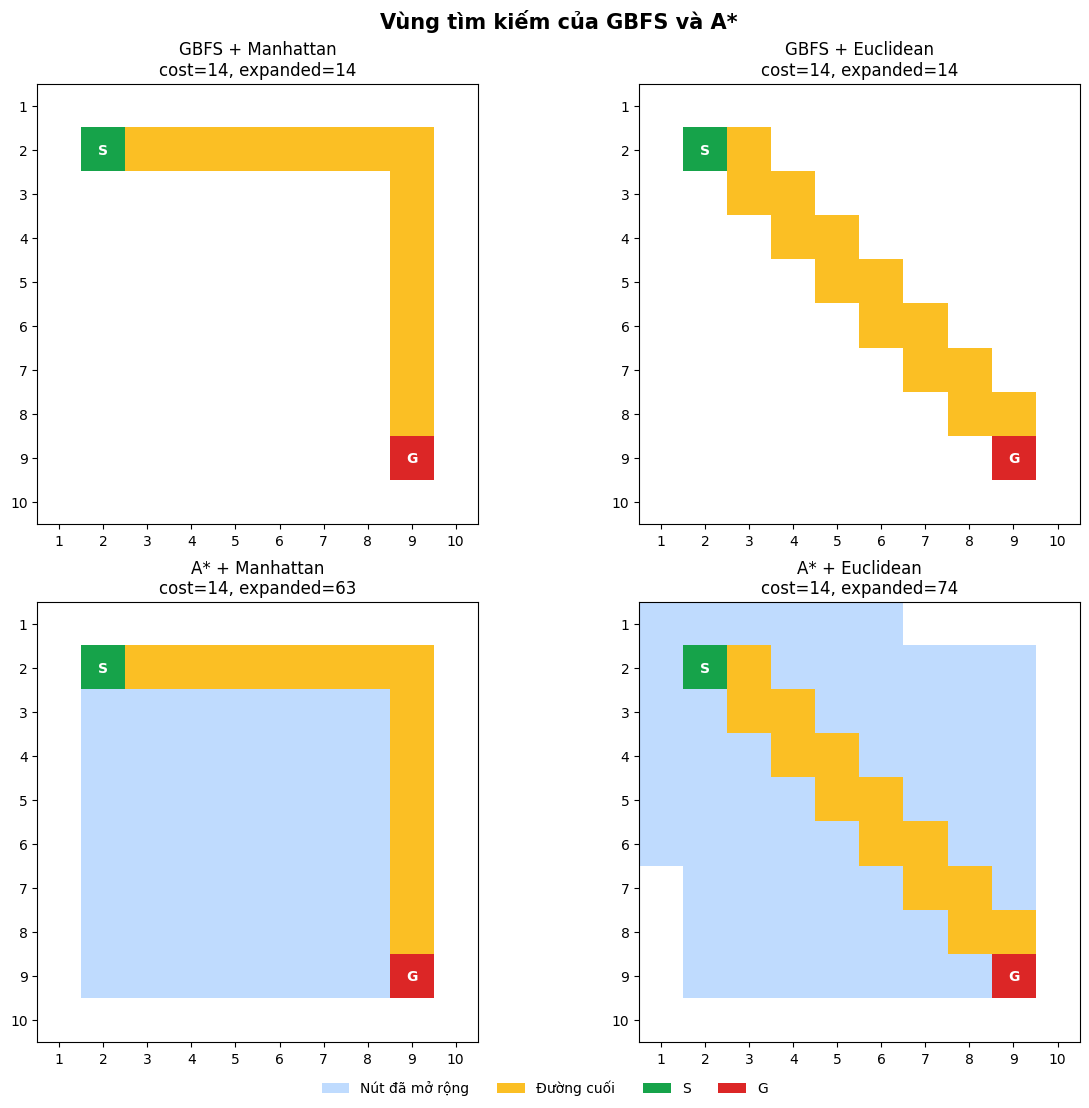

In [ ]:
# Xanh nhạt: đã mở rộng; vàng: đường cuối; xanh lá: S; đỏ: G.
search_cmap = ListedColormap(['#ffffff', '#bfdbfe', '#fbbf24', '#16a34a', '#dc2626'])
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)

for axis, result in zip(axes.flat, results):
    image = np.zeros((n, n), dtype=int)
    for state in result['expanded_order']:
        image[state] = 1
    for state in result['path'][1:-1]:
        image[state] = 2
    image[start_state] = 3
    image[goal_state] = 4
    axis.imshow(image, cmap=search_cmap, vmin=0, vmax=4, interpolation='nearest')
    axis.text(start_state[1], start_state[0], 'S', ha='center', va='center',
              color='white', fontweight='bold')
    axis.text(goal_state[1], goal_state[0], 'G', ha='center', va='center',
              color='white', fontweight='bold')
    axis.set_title(
        f"{result['strategy']} + {result['heuristic']}\n"
        f"cost={result['path_cost']}, expanded={result['expanded']}"
    )
    axis.set_xticks(range(n), labels=range(1, n + 1))
    axis.set_yticks(range(n), labels=range(1, n + 1))

legend = [
    Patch(facecolor='#bfdbfe', label='Nút đã mở rộng'),
    Patch(facecolor='#fbbf24', label='Đường cuối'),
    Patch(facecolor='#16a34a', label='S'),
    Patch(facecolor='#dc2626', label='G'),
]
fig.legend(handles=legend, loc='outside lower center', ncol=4, frameon=False)
fig.suptitle('Vùng tìm kiếm của GBFS và A*', fontsize=15, fontweight='bold')
plt.show()

## 6.3. Diễn giải kết quả so sánh

### GBFS

- Cả hai heuristic đều dẫn GBFS đến đích sau khi mở rộng 14 nút và đều tìm được đường 14 bước trong mê cung rỗng.
- Đây **không phải bằng chứng GBFS tối ưu**. GBFS chỉ nhìn $h$, không quan tâm chi phí đã đi $g$; khi có tường, nó có thể chọn đường trông gần đích nhưng thực tế phải đi vòng rất xa.
- Euclidean tạo hướng gần đường chéo; Manhattan tạo nhiều giá trị bằng nhau hơn. Vì thế số trạng thái được sinh và frontier có thể khác dù số nút mở rộng bằng nhau.

### A*

- A* + Manhattan mở rộng 63 nút; A* + Euclidean mở rộng 74 nút với quy tắc FIFO đang dùng. Cả hai vẫn trả đường tối ưu 14 bước.
- Manhattan **dominates** Euclidean trên lưới bốn hướng: $h_M(n)\ge h_E(n)$ tại mọi trạng thái, đồng thời cả hai không vượt quá chi phí thật. Heuristic lớn hơn nhưng vẫn admissible thường giúp A* loại được nhiều trạng thái hơn.
- Manhattan vẫn mở rộng khá nhiều vì plateau $f=14$. Nếu phá hòa bằng cách ưu tiên $h$ nhỏ hơn (gần đích hơn), A* có thể đi tới đích sớm hơn rất nhiều. Vì vậy khi so sánh heuristic phải công bố cả quy tắc phá hòa.

### Vì sao Manhattan phù hợp hơn?

Mỗi hành động chỉ thay đổi một tọa độ đúng một đơn vị. Để bù độ lệch $|\Delta r|$ theo hàng và $|\Delta c|$ theo cột, tác tử cần ít nhất $|\Delta r|+|\Delta c|$ bước. Trong mê cung rỗng, cận này đạt được nên Manhattan chính là chi phí thật. Euclidean đo đường thẳng—một chuyển động tác tử không được phép thực hiện—nên đánh giá thấp hơn. Khi có tường, Manhattan không còn hoàn hảo nhưng vẫn là cận dưới hợp lệ.

## 6.4. Heuristic khác và điều kiện bảo đảm tối ưu

Một lựa chọn khác là **Chebyshev**:

$$h_C(n)=\max(|r-r_G|, |c-c_G|).$$

Trên lưới bốn hướng, $h_C\le h_E\le h_M\le h^*$, nên Chebyshev admissible nhưng chứa ít thông tin hơn Manhattan và thường khiến A* mở rộng nhiều nút hơn. Nó hữu ích để minh họa rằng một heuristic đúng chưa chắc là heuristic mạnh. Một heuristic mạnh hơn có thể được tạo bằng cách chạy BFS ngược từ `G` để lưu khoảng cách thật tới đích; khi đó $h=h^*$, đổi lại phải tốn thời gian và bộ nhớ tiền xử lý.

Để A* graph search bảo đảm trả lời giải tối ưu, nên thỏa các điều kiện:

1. **Đích bằng 0:** $h(G)=0$.
2. **Admissible:** $0\le h(n)\le h^*(n)$; heuristic không được ước lượng vượt chi phí tối ưu còn lại.
3. **Consistent:** với mọi cạnh $n\rightarrow n'$ có chi phí $c(n,n')$,
   $$h(n)\le c(n,n')+h(n').$$
   Điều này làm $f$ không giảm dọc đường đi và cho phép đóng trạng thái sau lần mở rộng tốt nhất.
4. Chi phí bước phải không âm. Nếu heuristic chỉ admissible nhưng không consistent, cài đặt A* phải **mở lại** một trạng thái khi tìm được giá trị $g$ nhỏ hơn.

Manhattan, Euclidean và Chebyshev đều consistent cho di chuyển bốn hướng chi phí 1. Tuy nhiên Manhattan gần $h^*$ nhất trong ba heuristic, nên thường là lựa chọn phù hợp nhất.